In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [3]:
import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
from flax import linen as nn
import optax
import copy

from typing import Callable

from functools import partial

import tensorflow as tf
import tensorrt

from pyDOE import lhs
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import odeint

import numpy as np

from jax.scipy.optimize import minimize
from scipy.optimize import fsolve

import warnings

from collections import deque

In [4]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [5]:
print(jax.default_backend())

gpu


In [6]:
def Lorenz1960(vals, t):

  A_val, F_val, G_val = vals

  A_t = -(1/(k**2) - 1/(k**2 + l**2))*(k * l * F_val * G_val)
  F_t = (1/(l**2) - 1/(k**2 + l**2))*(k * l * A_val * G_val)
  G_t = -(1/2)*(1/(l**2) - 1/(k**2))*(k * l * A_val * F_val)

  vals_t = [A_t, F_t, G_t]

  return vals_t

In [7]:
t0, tfinal = 0.0, 1.0

In [8]:
k = 1.0
l = 2.0

k_sqr = k**2
l_sqr = l**2

In [9]:
class Normalize(nn.Module):
  xmin: float
  xmax: float

  @nn.compact
  def __call__(self, x):
    return 2.0*(x-self.xmin)/(self.xmax - self.xmin) - 1.0

In [10]:
class HardConstraint(nn.Module):
  t0: float
  tfinal: float
  u0: float

  @nn.compact
  def __call__(self, inputs):
    t, nn = inputs
    return self.u0 + (t-self.t0)/(self.tfinal-self.t0)*nn

In [11]:
class CombineBranches(nn.Module):
  @nn.compact
  def __call__(self, inp1, inp2):
    mult = jnp.sum(inp1*inp2, axis=1)
    out = jnp.reshape(mult, (-1,1))
    return out

In [12]:
class MLP(nn.Module):

  layers: int
  units: int

  @nn.compact
  def __call__(self, inp):
    b = inp
    for i in range(self.layers-1):
      b = nn.Dense(self.units)(b)
      b = nn.tanh(b)
    out = nn.Dense(3*self.units)(b)
    return out

In [13]:
def define_collocation_points(t_bdry, N=100):

  ode_points = t_bdry[0] + (t_bdry[1] - t_bdry[0])*lhs(1, N)

  As = np.random.uniform(-1.0, 1.0, size = (N, 1))
  Fs = np.random.uniform(-1.0, 1.0, size = (N, 1))
  Gs = np.random.uniform(-1.0, 1.0, size = (N, 1))
  Es = (1/4)*((As**2/l**2) + (Fs**2/k**2) + (2*(Gs**2)/(k**2 + l**2)))
  Vs = (1/2)*(As**2 + Fs**2 + 2*(Gs**2))

  sensor_points = np.column_stack((As, Fs, Gs, Es, Vs))

  return (ode_points, sensor_points)

In [14]:
(de_points, zsensors) = define_collocation_points([t0, tfinal], 1000)
print(de_points.shape, zsensors.shape)

(1000, 1) (1000, 5)


In [15]:
t_init_model = jnp.full((100, ), 1.0, dtype = jnp.float64)

In [16]:
print(de_points.dtype)
print(zsensors.dtype)
print(t_init_model.dtype)

float64
float64
float64


In [17]:
class DeepONet(nn.Module):

  t0: float
  tfinal: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, t, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    A_0 = u[:,:1]
    F_0 = u[:,1:2]
    G_0 = u[:,2:3]
    E_0 = u[:,3:4]
    V_0 = u[:,4:]

    u = u[:,:3]

    t = jnp.reshape(t, (-1,1))

    b = Normalize(self.t0, self.tfinal)(t)

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    A_tr = trunk_net[:,:self.units]
    F_tr = trunk_net[:,self.units:2*self.units]
    G_tr = trunk_net[:,2*self.units:]

    A_br = branch_net[:,:self.units]
    F_br = branch_net[:,self.units:2*self.units]
    G_br = branch_net[:,2*self.units:]

    A = CombineBranches()(A_tr, A_br)
    F = CombineBranches()(F_tr, F_br)
    G = CombineBranches()(G_tr, G_br)

    A = HardConstraint(self.t0, self.tfinal, A_0)([t, A])
    F = HardConstraint(self.t0, self.tfinal, F_0)([t, F])
    G = HardConstraint(self.t0, self.tfinal, G_0)([t, G])

    A = jnp.reshape(A, (-1,))
    F = jnp.reshape(F, (-1,))
    G = jnp.reshape(G, (-1,))

    return A, F, G

In [18]:
@partial(jax.jit, static_argnums=(2,))
def var_model(t, z, component, params):
  return deeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def var(t, z, component, params):
  return jax.vmap(var_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def var_t(t, z, component, params):
  return jax.vmap(jax.grad(var_model, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def loss(params, t, z):

    A_t_loss_w = 1.0
    F_t_loss_w = 1.0
    G_t_loss_w = 1.0
    
    diff_loss_w = 1.0
    E_loss_w = 1.0
    V_loss_w = 1.0
    
    E_0_val = z[:, -2]
    V_0_val = z[:, -1]
    
    A_val = var(t, z, 0, params)
    F_val = var(t, z, 1, params)
    G_val = var(t, z, 2, params)
    
    A_t_val = var_t(t, z, 0, params)
    F_t_val = var_t(t, z, 1, params)
    G_t_val = var_t(t, z, 2, params)
    
    
    E_val = (0.25)*((A_val**2/l**2) + (F_val**2/k**2) + (2.*(G_val**2)/(k**2 + l**2)))
    E_loss = E_val - E_0_val
    E_loss = jnp.square(E_loss)
    E_loss = jnp.mean(E_loss)
    
    V_val = (0.5)*(A_val**2 + F_val**2 + 2.*(G_val**2))
    V_loss = V_val - V_0_val
    V_loss = jnp.square(V_loss)
    V_loss = jnp.mean(V_loss)
        
    A_t_loss = A_t_val + (1./(k**2) - 1./(k**2 + l**2))*(k * l * F_val * G_val)
    A_t_loss = jnp.square(A_t_loss)
    A_t_loss = jnp.mean(A_t_loss)
    
    F_t_loss = F_t_val - (1./(l**2) - 1./(k**2 + l**2))*(k * l * A_val * G_val)
    F_t_loss = jnp.square(F_t_loss)
    F_t_loss = jnp.mean(F_t_loss)
    
    G_t_loss = G_t_val + (0.5)*(1./(l**2) - 1./(k**2))*(k * l * A_val * F_val)
    G_t_loss = jnp.square(G_t_loss)
    G_t_loss = jnp.mean(G_t_loss)
    
    diff_loss = A_t_loss_w*A_t_loss + F_t_loss_w*F_t_loss + G_t_loss_w*G_t_loss
    
    final_loss = diff_loss_w*diff_loss + E_loss_w*E_loss + V_loss_w*V_loss
    
    return final_loss

@jax.jit
def train_step(params, pdes, z):
    t = pdes[:,0]
    
    return jax.value_and_grad(loss)(params, t, z)

@partial(jax.jit, static_argnums=(3,))
def optimize(grads, opt_state, params, optimizer_update):
    updates, opt_state = optimizer_update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state

In [19]:
def train_network(params, des, sensors, epochs=100):

  N = de_points.shape[0]

  nr_batches = 10
  batch_size = len(des)//nr_batches

  print("batch size:", batch_size)

  lr = 1e-3
  optimizer = optax.yogi(lr)
  opt_state = optimizer.init(params)

  ds_z = tf.data.Dataset.from_tensor_slices(sensors)
  ds_de = tf.data.Dataset.from_tensor_slices(des)

  ds = tf.data.Dataset.zip((ds_de, ds_z))
  ds = ds.shuffle(N).batch(batch_size)

  epoch_loss = np.zeros(epochs)

  for i in range(epochs):

    for (des_batch, z_batch) in ds:

      loss, grads = train_step(params, des_batch.numpy(), z_batch.numpy())
      params, opt_state = optimize(grads, opt_state, params, optimizer.update)

      epoch_loss[i] += loss

    epoch_loss[i] /= batch_size

    if i % 100  == 0:
      print(f'Loss in epoch {i}: {epoch_loss[i]}')

  return params, epoch_loss

In [20]:
deeponet = DeepONet(t0, tfinal, layers=4, units=40)

t_init = jnp.full((10, ), 1.0)
u_init = jnp.full((10, 5), 1.0)

params = deeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [21]:
param_count = sum(x.size for x in jax.tree.leaves(params))
print(param_count)

16640


In [22]:
epochs = 5000
params, loss = train_network(params, de_points, zsensors, epochs)

batch size: 100
Loss in epoch 0: 0.1685161048725724
Loss in epoch 100: 0.001506657230335076
Loss in epoch 200: 0.0007694779453073032
Loss in epoch 300: 0.0003878144627200667
Loss in epoch 400: 0.00027372083997921366
Loss in epoch 500: 0.0002317963551924837
Loss in epoch 600: 0.00016702082155648575
Loss in epoch 700: 0.00018449574043484653
Loss in epoch 800: 0.00014220453995256464
Loss in epoch 900: 9.943420522232677e-05
Loss in epoch 1000: 9.483111516910802e-05
Loss in epoch 1100: 8.26797970118573e-05
Loss in epoch 1200: 8.348789507102099e-05
Loss in epoch 1300: 7.423268890084317e-05
Loss in epoch 1400: 6.967605662068981e-05
Loss in epoch 1500: 4.748210807623886e-05
Loss in epoch 1600: 5.0610589322866255e-05
Loss in epoch 1700: 6.309302366762481e-05
Loss in epoch 1800: 5.598137985121077e-05
Loss in epoch 1900: 5.413143772656904e-05
Loss in epoch 2000: 5.194391502802289e-05
Loss in epoch 2100: 4.4142035591720806e-05
Loss in epoch 2200: 5.584201875193793e-05
Loss in epoch 2300: 5.4261856

In [1]:
loss_adam = loss

NameError: name 'loss' is not defined

In [ ]:
plt.semilogy(loss_adam)
plt.grid()

In [25]:
n = 500
t = np.linspace(t0, tfinal, n)

A_data = np.random.uniform(-1.0, 1.0, size=(1,))
F_data = np.random.uniform(-1.0, 1.0, size=(1,))
G_data = np.random.uniform(-1.0, 1.0, size=(1,))
E_data = (1/4)*((A_data**2/l**2) + (F_data**2/k**2) + (2*(G_data**2)/(k**2 + l**2)))
V_data = (1/2)*(A_data**2 + F_data**2 + 2*(G_data**2))

init_data = np.column_stack([A_data, F_data, G_data])
init_data_E_V = np.column_stack([A_data, F_data, G_data, E_data, V_data])

init_data = np.reshape(init_data, (-1,))
init_data_E_V = np.reshape(init_data_E_V, (-1,))

z_init = np.repeat(np.expand_dims(init_data, axis=0), len(t), axis=0)
z_init_E_V = np.repeat(np.expand_dims(init_data_E_V, axis=0), len(t), axis=0)

print(z_init.shape, z_init_E_V.shape)

(500, 3) (500, 5)


In [26]:
sol_rk = odeint(Lorenz1960, init_data, t)
A_rk, F_rk, G_rk = sol_rk[:,0], sol_rk[:,1], sol_rk[:,2]
E_rk = (1/4)*((A_rk**2/l**2) + (F_rk**2/k**2) + (2*(G_rk**2)/(k**2 + l**2)))
V_rk = (1/2)*(A_rk**2 + F_rk**2 + 2*(G_rk**2))

In [27]:
A_van = jax.vmap(var_model, [0, 0, None, None])(t, z_init_E_V, 0, params)
F_van = jax.vmap(var_model, [0, 0, None, None])(t, z_init_E_V, 1, params)
G_van = jax.vmap(var_model, [0, 0, None, None])(t, z_init_E_V, 2, params)
E_van = (1/4)*((A_van**2/l**2) + (F_van**2/k**2) + (2*(G_van**2)/(k**2 + l**2)))
V_van = (1/2)*(A_van**2 + F_van**2 + 2*(G_van**2))

z_van = jnp.column_stack([A_van, F_van, G_van, E_van, V_van])

print(z_van.shape)

(500, 5)


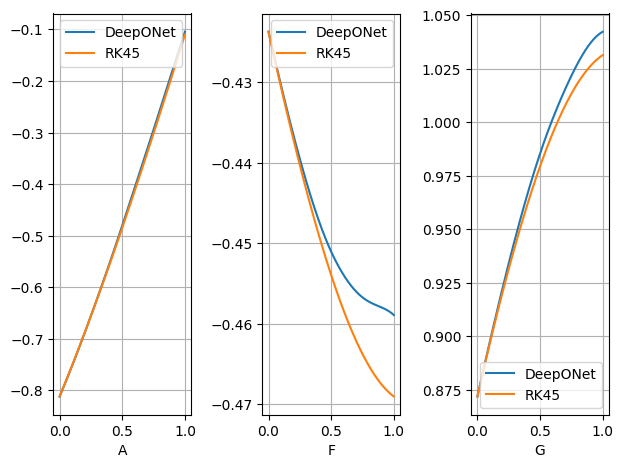

In [28]:
fig = plt.figure()

plt.subplot(1, 3, 1)
plt.tight_layout()
plt.plot(t, A_van)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(1, 3, 2)
plt.tight_layout()
plt.plot(t, F_van)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(1, 3, 3)
plt.tight_layout()
plt.plot(t, G_van)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.show()

In [29]:
AFG_vals = jnp.column_stack((A_van, F_van, G_van))
E_vals = z_init_E_V[:, 3:4]
V_vals = z_init_E_V[:, 4:]

print(AFG_vals.shape, E_vals.shape, V_vals.shape)

(500, 3) (500, 1) (500, 1)


In [30]:
def err_func(x, E_0, V_0) :

    factor_E = 1.0
    # factor_V = E_0/V_0
    factor_V = 1.0
    
    A, F, G = x
    E = (0.25)*((A**2/l**2) + (F**2/k**2) + (2.*(G**2)/(k**2 + l**2)))
    V = (1/2)*(A**2 + F**2 + 2*(G**2))

    E_err = (E - E_0)**2
    V_err = (V - V_0)**2

    err_total = factor_E*E_err + factor_V*V_err

    return err_total[0]

In [31]:
def find_min_sci_bfgs(x, E_0, V_0):
    
    return minimize(err_func, x, (E_0, V_0), method='BFGS', tol = 1e-7)

In [32]:
result = jax.vmap(find_min_sci_bfgs, (0, 0, 0), 0)(AFG_vals, E_vals, V_vals)
result = result.x

A_res = result[:, 0]
F_res = result[:, 1]
G_res = result[:, 2]
E_res = (1/4)*((A_res**2/l**2) + (F_res**2/k**2) + (2*(G_res**2)/(k**2 + l**2)))
V_res = (1/2)*(A_res**2 + F_res**2 + 2*(G_res**2))

print(A_res.shape, F_res.shape, G_res.shape, E_res.shape, V_res.shape)

(500,) (500,) (500,) (500,) (500,)


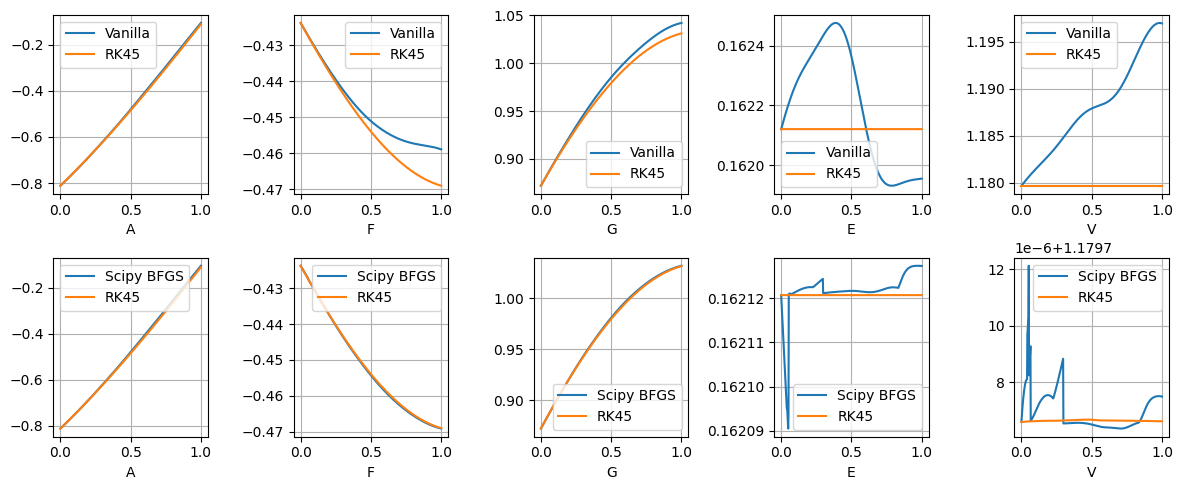

In [33]:
fig = plt.figure(figsize=(12, 5))

plt.subplot(2, 5, 1)
plt.tight_layout()
plt.plot(t, A_van)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(2, 5, 2)
plt.tight_layout()
plt.plot(t, F_van)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(2, 5, 3)
plt.tight_layout()
plt.plot(t, G_van)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(2, 5, 4)
plt.tight_layout()
plt.plot(t, E_van)
plt.plot(t, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['Vanilla','RK45'])


plt.subplot(2, 5, 5)
plt.tight_layout()
plt.plot(t, V_van)
plt.plot(t, V_rk)
plt.xlabel("V")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(2, 5, 6)
plt.tight_layout()
plt.plot(t, A_res)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['Scipy BFGS','RK45'])

plt.subplot(2, 5, 7)
plt.tight_layout()
plt.plot(t, F_res)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['Scipy BFGS','RK45'])

plt.subplot(2, 5, 8)
plt.tight_layout()
plt.plot(t, G_res)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['Scipy BFGS','RK45'])

plt.subplot(2, 5, 9)
plt.tight_layout()
plt.plot(t, E_res)
plt.plot(t, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['Scipy BFGS','RK45'])


plt.subplot(2, 5, 10)
plt.tight_layout()
plt.plot(t, V_res)
plt.plot(t, V_rk)
plt.xlabel("V")
plt.grid()
plt.legend(['Scipy BFGS','RK45'])


plt.show()

In [88]:
@jax.jit
def gradD_fun(x, E_0, V_0) :

    factor_E = 1.0
    # factor_V = E_0/V_0
    factor_V = 1.0

    A = x[0]
    F = x[1]
    G = x[2]
    
    dE_dA = A/(2*(l**2))
    dE_dF = F/(2*(k**2))
    dE_dG = G/(k**2 + l**2)

    dV_dA = A
    dV_dF = F
    dV_dG = 2*G
  
    E = (1/4)*((A**2/l**2) + (F**2/k**2) + (2*(G**2)/(k**2 + l**2)))
    V = (1/2)*(A**2 + F**2 + 2*(G**2))

    dD_dA = 2*factor_E*(E-E_0)*dE_dA + 2*factor_V*(V-V_0)*dV_dA
    dD_dF = 2*factor_E*(E-E_0)*dE_dF + 2*factor_V*(V-V_0)*dV_dF
    dD_dG = 2*factor_E*(E-E_0)*dE_dG + 2*factor_V*(V-V_0)*dV_dG

    deriv_D_arr = jnp.array([dD_dA, dD_dF, dD_dG])

    return deriv_D_arr


In [89]:
@jax.jit
def D_fun(x, E_0, V_0) :

    factor_E = 1.0
    # factor_V = E_0/V_0
    factor_V = 1.0
    
    A = x[0]
    F = x[1]
    G = x[2]
        
    E = (1/4)*((A**2/l**2) + (F**2/k**2) + (2.*(G**2)/(k**2 + l**2)))
    V = (1/2)*(A**2 + F**2 + 2*(G**2))

    D = factor_E*((E - E_0)**2) + factor_V*((V - V_0)**2)

    D_arr = jnp.array([D])

    return D_arr

In [90]:
@jax.jit
def find_rec(x):
    
    x = x + jnp.finfo(jnp.float64).eps
    
    return 1/x

In [91]:
@jax.jit
def wolfe_conds(args):

    alpha, curr_x, curr_f, curr_grad, next_x, next_f, next_grad, p, E_0, V_0, iter = args

    c1 = 1e-4

    cond = next_f - curr_f - c1*alpha*(curr_grad.T@p)

    cond_bool = jax.lax.cond(cond[0][0] > 0.0 , lambda x: True, lambda x: False, None)
    final_bool = cond_bool
    
    return final_bool

In [92]:
@jax.jit
def update_alpha(args) :

    alpha, curr_x, curr_f, curr_grad, next_x, next_f, next_grad, p, E_0, V_0, iter = args

    alpha = alpha*0.1
    iter = iter + 1
        
    next_x = curr_x + alpha*p
    next_f = D_fun(next_x, E_0, V_0)
    next_grad = gradD_fun(next_x, E_0, V_0) 
   
    return (alpha, curr_x, curr_f, curr_grad, next_x, next_f, next_grad, p, E_0, V_0, iter)


In [93]:
@jax.jit
def BFGS(x, E_0, V_0) :

    iter_num = 0
    init_iter = 0
    alpha = 1.0
    I_3 = jnp.identity(3, dtype = jnp.float64)
    B_0_inv = jnp.identity(3, dtype = jnp.float64)

    x_0 = x
    x_0 = jnp.reshape(x_0, (-1, 1))

    D_0 = D_fun(x_0, E_0, V_0)
    gradD_0 = gradD_fun(x_0, E_0, V_0)

    p = -(B_0_inv@gradD_0)

    pot_x = x_0 + alpha*p
    pot_D = D_fun(pot_x, E_0, V_0)
    pot_gradD = gradD_fun(pot_x, E_0, V_0)

    init_args = (alpha, x_0, D_0, gradD_0, pot_x, pot_D, pot_gradD, p, E_0, V_0, init_iter)
    
    step, _, _, _, _, _, _, _, _, _, _ = jax.lax.while_loop(wolfe_conds, update_alpha, init_args)

    x_1 = x_0 + step*p

    while iter_num < 5:

        delta_x = x_1 - x_0

        D_1 = D_fun(x_1, E_0, V_0)
        gradD_1 = gradD_fun(x_1, E_0, V_0)

        y = gradD_1 - gradD_0       

        y_T_delta_x = y.T@delta_x
        y_T_delta_x_rec = find_rec(y_T_delta_x)
        
        B_1_inv = ((I_3 - (y_T_delta_x_rec*(delta_x@y.T)))@B_0_inv@(I_3 - (y_T_delta_x_rec*(y@delta_x.T)))) + (y_T_delta_x_rec*(delta_x@delta_x.T))   
        p = -(B_1_inv@gradD_1)
        
        pot_x = x_1 + alpha*p
        pot_D = D_fun(pot_x, E_0, V_0)
        pot_gradD = gradD_fun(pot_x, E_0, V_0) 
                  
        init_args = (alpha, x_1, D_1, gradD_1, pot_x, pot_D, pot_gradD, p, E_0, V_0, init_iter)

        step, _, _, _, _, _, _, _, _, _, _ = jax.lax.while_loop(wolfe_conds, update_alpha, init_args)

        x_temp = x_1 + step*p

        x_0 = x_1
        x_1 = x_temp

        D_0 = D_1
        gradD_0 = gradD_1

        B_0_inv = B_1_inv
        
        iter_num = iter_num + 1

    A = x_1[0]
    F = x_1[1]
    G = x_1[2]

    A = jnp.reshape(A, (-1, ))[0]
    F = jnp.reshape(F, (-1, ))[0]
    G = jnp.reshape(G, (-1, ))[0]


    return x_1

In [94]:
@jax.jit
def find_min_bfgs(x, E_0, V_0) :

    return jax.vmap(BFGS, (0, 0, 0), 0)(x, E_0, V_0)

In [95]:
AFG_vals = z_van[:, :3]
E_vals = z_init_E_V[:, -2:-1]
V_vals = z_init_E_V[:, -1:]

print(AFG_vals.shape, E_vals.shape, V_vals.shape)

(500, 3) (500, 1) (500, 1)


In [96]:
x_bfgs = find_min_bfgs(AFG_vals, E_vals, V_vals)

A_bfgs = jnp.reshape(x_bfgs[:,:1], (-1,))
F_bfgs = jnp.reshape(x_bfgs[:,1:2], (-1,))
G_bfgs = jnp.reshape(x_bfgs[:,2:3], (-1,))
E_bfgs = (1/4)*((A_bfgs**2/l**2) + (F_bfgs**2/k**2) + (2*(G_bfgs**2)/(k**2 + l**2)))
V_bfgs = (1/2)*(A_bfgs**2 + F_bfgs**2 + 2*(G_bfgs**2))

result_sci = jax.vmap(find_min_sci_bfgs, (0, 0, 0), 0)(AFG_vals, E_vals, V_vals)
result_sci = result_sci.x

A_sci = result_sci[:, 0]
F_sci = result_sci[:, 1]
G_sci = result_sci[:, 2]
E_sci = (1/4)*((A_sci**2/l**2) + (F_sci**2/k**2) + (2*(G_sci**2)/(k**2 + l**2)))
V_sci = (1/2)*(A_sci**2 + F_sci**2 + 2*(G_sci**2))

print(A_sci.shape, A_sci.shape)

(500,) (500,)


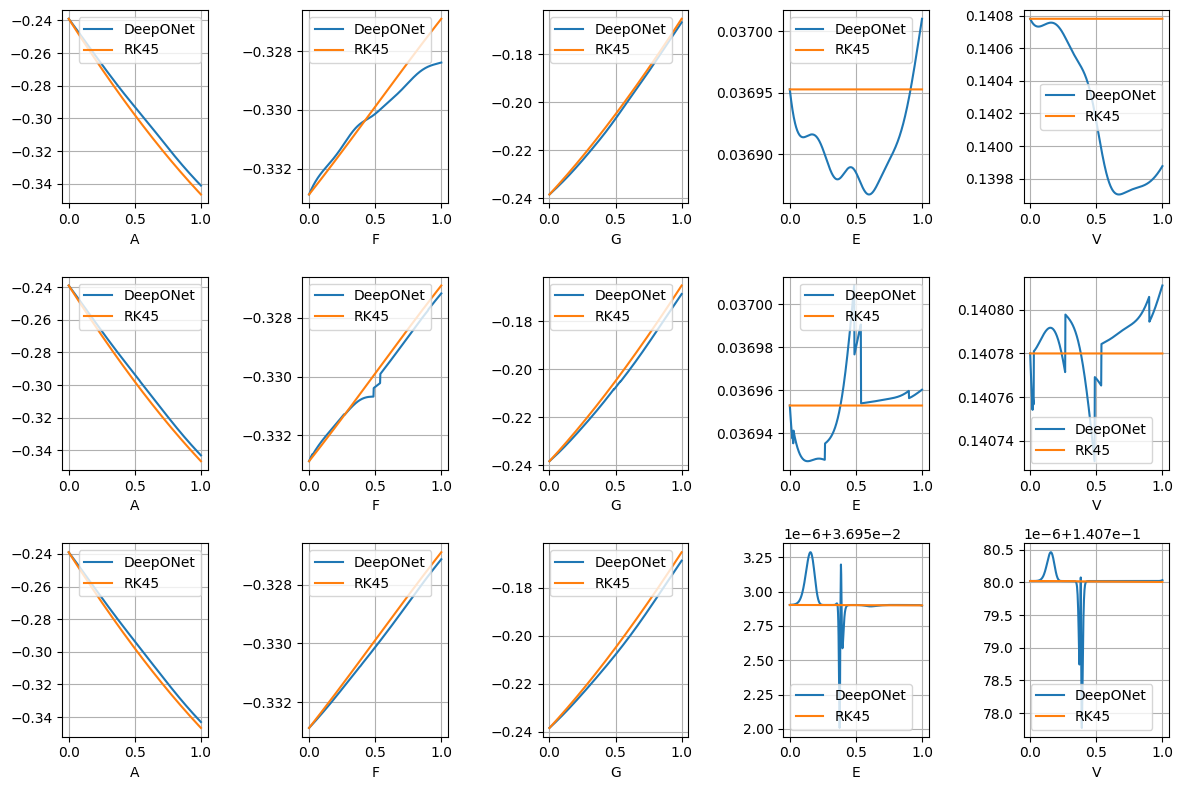

In [97]:
fig = plt.figure(figsize=(12, 8))

plt.subplot(3, 5, 1)
plt.tight_layout()
plt.plot(t, A_van)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(3, 5, 2)
plt.tight_layout()
plt.plot(t, F_van)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(3, 5, 3)
plt.tight_layout()
plt.plot(t, G_van)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(3, 5, 4)
plt.tight_layout()
plt.plot(t, E_van)
plt.plot(t, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['DeepONet','RK45'])


plt.subplot(3, 5, 5)
plt.tight_layout()
plt.plot(t, V_van)
plt.plot(t, V_rk)
plt.xlabel("V")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(3, 5, 6)
plt.tight_layout()
plt.plot(t, A_sci)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(3, 5, 7)
plt.tight_layout()
plt.plot(t, F_sci)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(3, 5, 8)
plt.tight_layout()
plt.plot(t, G_sci)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(3, 5, 9)
plt.tight_layout()
plt.plot(t, E_sci)
plt.plot(t, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['DeepONet','RK45'])


plt.subplot(3, 5, 10)
plt.tight_layout()
plt.plot(t, V_sci)
plt.plot(t, V_rk)
plt.xlabel("V")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(3, 5, 11)
plt.tight_layout()
plt.plot(t, A_bfgs)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(3, 5, 12)
plt.tight_layout()
plt.plot(t, F_bfgs)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(3, 5, 13)
plt.tight_layout()
plt.plot(t, G_bfgs)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(3, 5, 14)
plt.tight_layout()
plt.plot(t, E_bfgs)
plt.plot(t, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['DeepONet','RK45'])


plt.subplot(3, 5, 15)
plt.tight_layout()
plt.plot(t, V_bfgs)
plt.plot(t, V_rk)
plt.xlabel("V")
plt.grid()
plt.legend(['DeepONet','RK45'])


plt.show()

In [98]:
# def insert_nans(arr, limit = 1.0) :

#     arr = jnp.where(jnp.abs(arr) > limit, jnp.nan, arr)

#     return arr

In [99]:
def flatten_pytree(params):
  values, tree_info = jax.tree_util.tree_flatten(params)

  no_leaves = len(values)
  shapes = []
  flattened = []

  for i in range(no_leaves):
    flattened.append(values[i].flatten())
    shapes.append(values[i].shape)

  return tree_info, shapes, jnp.concatenate(flattened)


def reconstruct_pytree(tree_info, shapes, flattened):

  values = []
  k = 0
  for i in range(len(shapes)):
    values.append(np.reshape(flattened[k:k+np.prod(shapes[i])], shapes[i]))
    k += np.prod(shapes[i])

  py_tree = jax.tree_util.tree_unflatten(tree_info, values)
  return py_tree

In [100]:
class ClosestPoint(nn.Module):

    E_0: float
    V_0: float
    
    @nn.compact
    def __call__(self, inputs):
    
        z_min = find_min_bfgs(inputs, self.E_0, self.V_0)
    
        return z_min

In [101]:
class CDeepONet(nn.Module):

  t0: float
  tfinal: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, t, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    A_0 = u[:,:1]
    F_0 = u[:,1:2]
    G_0 = u[:,2:3]
    E_0 = u[:,3:4]
    V_0 = u[:,4:]

    u = u[:,:3]

    t = jnp.reshape(t, (-1,1))

    b = Normalize(self.t0, self.tfinal)(t)

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    A_tr = trunk_net[:,:self.units]
    F_tr = trunk_net[:,self.units:2*self.units]
    G_tr = trunk_net[:,2*self.units:]

    A_br = branch_net[:,:self.units]
    F_br = branch_net[:,self.units:2*self.units]
    G_br = branch_net[:,2*self.units:]
      
    A = CombineBranches()(A_tr, A_br)
    F = CombineBranches()(F_tr, F_br)
    G = CombineBranches()(G_tr, G_br)

    A = HardConstraint(self.t0, self.tfinal, A_0)([t, A])
    F = HardConstraint(self.t0, self.tfinal, F_0)([t, F])
    G = HardConstraint(self.t0, self.tfinal, G_0)([t, G])

    z = jnp.column_stack([A, F, G])
    z = ClosestPoint(E_0, V_0)(z)   

    A = z[:, :1]
    F = z[:, 1:2]
    G = z[:, 2:3]
      
    A = jnp.reshape(A, (-1,))
    F = jnp.reshape(F, (-1,))
    G = jnp.reshape(G, (-1,))

    return A, F, G

In [102]:
@partial(jax.jit, static_argnums=(2,))
def Cvar_model(t, z, component, params):
  return Cdeeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def Cvar(t, z, component, params):
  return jax.vmap(Cvar_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def Cvar_t(t, z, component, params):
  return jax.vmap(jax.grad(Cvar_model, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def Closs(params, t, z):
    
    A_t_loss_w = 1.0
    F_t_loss_w = 1.0
    G_t_loss_w = 1.0
    
    diff_loss_w = 1.0
    E_loss_w = 0.0
    V_loss_w = 0.0
    
    E_0_val = z[:, -2:-1]
    V_0_val = z[:, -1:]
    
    A_val = Cvar(t, z, 0, params)
    F_val = Cvar(t, z, 1, params)
    G_val = Cvar(t, z, 2, params)
    
    A_t_val = Cvar_t(t, z, 0, params)  
    F_t_val = Cvar_t(t, z, 1, params)
    G_t_val = Cvar_t(t, z, 2, params)


    # A_t_val = insert_nans(A_t_val)
    # F_t_val = insert_nans(F_t_val)
    # G_t_val = insert_nans(G_t_val)

    # A_t_val_mask = jnp.isnan(A_t_val)
    # F_t_val_mask = jnp.isnan(F_t_val)
    # G_t_val_mask = jnp.isnan(G_t_val)

    # final_mask = jnp.logical_or(A_t_val_mask, F_t_val_mask)
    # final_mask = jnp.logical_or(final_mask, G_t_val_mask)

    # A_val = jnp.where(final_mask, 0., A_val)
    # F_val = jnp.where(final_mask, 0., F_val)
    # G_val = jnp.where(final_mask, 0., G_val)
    # A_t_val = jnp.where(final_mask, 0., A_t_val)
    # F_t_val = jnp.where(final_mask, 0., F_t_val)
    # G_t_val = jnp.where(final_mask, 0., G_t_val) 

    
    E_val = (0.25)*((A_val**2/l**2) + (F_val**2/k**2) + (2.*(G_val**2)/(k**2 + l**2)))
    E_loss = E_val - E_0_val
    E_loss = jnp.square(E_loss)
    E_loss = jnp.mean(E_loss)  
    
    V_val = (0.5)*(A_val**2 + F_val**2 + 2*(G_val**2))
    V_loss = V_val - V_0_val
    V_loss = jnp.square(V_loss)
    V_loss = jnp.mean(V_loss)

    A_t_loss = A_t_val + (1./(k**2) - 1./(k**2 + l**2))*(k * l * F_val * G_val)
    A_t_loss = jnp.square(A_t_loss)
    A_t_loss = jnp.mean(A_t_loss)
    
    F_t_loss = F_t_val - (1./(l**2) - 1./(k**2 + l**2))*(k * l * A_val * G_val)
    F_t_loss = jnp.square(F_t_loss)
    F_t_loss = jnp.mean(F_t_loss)
    
    G_t_loss = G_t_val + (0.25)*(1./(l**2) - 1./(k**2))*(k * l * A_val * F_val)
    G_t_loss = jnp.square(G_t_loss)
    G_t_loss = jnp.mean(G_t_loss)
    
    diff_loss = A_t_loss_w*A_t_loss + F_t_loss_w*F_t_loss + G_t_loss_w*G_t_loss
    
    final_loss = diff_loss_w*diff_loss + E_loss_w*E_loss + V_loss_w*V_loss

    return final_loss

@jax.jit
def Ctrain_step(params, pdes, z):
  t = pdes[:,0]
    
  return jax.value_and_grad(Closs)(params, t, z)

@partial(jax.jit, static_argnums=(3,))
def Coptimize(grads, opt_state, params, optimizer_update):
  updates, opt_state = optimizer_update(grads, opt_state, params)
  params = optax.apply_updates(params, updates)
  return params, opt_state

In [103]:
def Ctrain_network(params, des, sensors, epochs=100):

    N = de_points.shape[0]
    
    nr_batches = 10
    batch_size = len(des)//nr_batches
    
    print("batch size:", batch_size)
    
    lr = 1e-3
    optimizer = optax.yogi(lr)
    opt_state = optimizer.init(params)
    
    ds_z = tf.data.Dataset.from_tensor_slices(sensors)
    ds_de = tf.data.Dataset.from_tensor_slices(des)
    
    ds = tf.data.Dataset.zip((ds_de, ds_z))
    ds = ds.shuffle(N).batch(batch_size)
    
    epoch_loss = np.zeros(epochs)
    
    for i in range(epochs):

        batch_no = 0
    
        for (des_batch, z_batch) in ds:
    
            loss, grads = Ctrain_step(params, des_batch.numpy(), z_batch.numpy())
            
            params, opt_state = Coptimize(grads, opt_state, params, optimizer.update)
            
            epoch_loss[i] += loss

            batch_no = batch_no + 1

        epoch_loss[i] /= batch_size

        if i % 1  == 0:
            print(f'Loss in epoch {i}: {epoch_loss[i]}')

    return params, epoch_loss

In [104]:
Cdeeponet = CDeepONet(t0, tfinal, layers=4, units=40)

t_init = jnp.full((10, ), 1.0, dtype = jnp.float64)
u_init = jnp.full((10, 5), 1.0, dtype = jnp.float64 )

Cparams = Cdeeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [105]:
Cparam_count = sum(x.size for x in jax.tree.leaves(Cparams))
print(Cparam_count)

16640


In [106]:
Cparams = copy.deepcopy(params)

In [107]:
tree_info, shapes, Cparams_flat = flatten_pytree(Cparams)

In [108]:
# epochs = 100
# Cparams, loss = Ctrain_network(Cparams, de_points, zsensors, epochs)

# plt.semilogy(loss)
# plt.grid()

In [109]:
# A = jax.vmap(Cvar_model, [0, 0, None, None])(t, z, 0, Cparams)
# F = jax.vmap(Cvar_model, [0, 0, None, None])(t, z, 1, Cparams)
# G = jax.vmap(Cvar_model, [0, 0, None, None])(t, z, 2, Cparams)
# E = (1/4)*((A**2/l**2) + (F**2/k**2) + (2*(G**2)/(k**2 + l**2)))
# V = (1/2)*(A**2 + F**2 + 2*(G**2))

In [110]:
# fig = plt.figure(figsize=(12, 10))

# plt.subplot(3, 5, 1)
# plt.tight_layout()
# plt.plot(t, A_van)
# plt.plot(t, A_rk)
# plt.xlabel("A")
# plt.grid()
# plt.legend(['Vanilla','RK45'])

# plt.subplot(3, 5, 2)
# plt.tight_layout()
# plt.plot(t, F_van)
# plt.plot(t, F_rk)
# plt.xlabel("F")
# plt.grid()
# plt.legend(['Vanilla','RK45'])

# plt.subplot(3, 5, 3)
# plt.tight_layout()
# plt.plot(t, G_van)
# plt.plot(t, G_rk)
# plt.xlabel("G")
# plt.grid()
# plt.legend(['Vanilla','RK45'])

# plt.subplot(3, 5, 4)
# plt.tight_layout()
# plt.plot(t, E_van)
# plt.plot(t, E_rk)
# plt.xlabel("E")
# plt.grid()
# plt.legend(['Vanilla','RK45'])


# plt.subplot(3, 5, 5)
# plt.tight_layout()
# plt.plot(t, V_van)
# plt.plot(t, V_rk)
# plt.xlabel("V")
# plt.grid()
# plt.legend(['Vanilla','RK45'])

# plt.subplot(3, 5, 6)
# plt.tight_layout()
# plt.plot(t, A_bfgs)
# plt.plot(t, A_rk)
# plt.xlabel("A")
# plt.grid()
# plt.legend(['BFGS w/o Train','RK45'])

# plt.subplot(3, 5, 7)
# plt.tight_layout()
# plt.plot(t, F_bfgs)
# plt.plot(t, F_rk)
# plt.xlabel("F")
# plt.grid()
# plt.legend(['BFGS w/o Train','RK45'])

# plt.subplot(3, 5, 8)
# plt.tight_layout()
# plt.plot(t, G_bfgs)
# plt.plot(t, G_rk)
# plt.xlabel("G")
# plt.grid()
# plt.legend(['BFGS w/o Train','RK45'])

# plt.subplot(3, 5, 9)
# plt.tight_layout()
# plt.plot(t, E_bfgs)
# plt.plot(t, E_rk)
# plt.xlabel("E")
# plt.grid()
# plt.legend(['BFGS w/o Train','RK45'])


# plt.subplot(3, 5, 10)
# plt.tight_layout()
# plt.plot(t, V_bfgs)
# plt.plot(t, V_rk)
# plt.xlabel("V")
# plt.grid()
# plt.legend(['BFGS w/o Train','RK45'])


# plt.subplot(3, 5, 11)
# plt.tight_layout()
# plt.plot(t, A)
# plt.plot(t, A_rk)
# plt.xlabel("A")
# plt.grid()
# plt.legend(['BFGS w/ Train','RK45'])

# plt.subplot(3, 5, 12)
# plt.tight_layout()
# plt.plot(t, F)
# plt.plot(t, F_rk)
# plt.xlabel("F")
# plt.grid()
# plt.legend(['BFGS w/ Train','RK45'])

# plt.subplot(3, 5, 13)
# plt.tight_layout()
# plt.plot(t, G)
# plt.plot(t, G_rk)
# plt.xlabel("G")
# plt.grid()
# plt.legend(['BFGS w/ Train','RK45'])

# plt.subplot(3, 5, 14)
# plt.tight_layout()
# plt.plot(t, E)
# plt.plot(t, E_rk)
# plt.xlabel("E")
# plt.grid()
# plt.legend(['BFGS w/ Train','RK45'])


# plt.subplot(3, 5, 15)
# plt.tight_layout()
# plt.plot(t, V)
# plt.plot(t, V_rk)
# plt.xlabel("V")
# plt.grid()
# plt.legend(['BFGS w/ Train','RK45'])


# plt.show()

In [111]:
# tree_info, shapes, Cparams_flat = flatten_pytree(Cparams)
# Cparams_flat_10_ep = jax.numpy.load("Cparams_flat_10_ep.npy")
# Cparams = reconstruct_pytree(tree_info, shapes, Cparams_flat_10_ep)

In [112]:
@jax.jit
def loss_fun(params, t, z):
    
    return Closs(params, t, z)


@jax.jit
def loss_grad_fun(params, t, z):
    
      return jax.grad(loss_fun)(params, t, z)

In [113]:
@jax.jit
def computeH0(y, s):

  numerator = y.T@s
  denominator = y.T@y
  gamma = jnp.where(denominator > 0, numerator/denominator, 1.0)
  return gamma*jnp.eye(s.shape[0])

In [114]:
@jax.jit
def lineSearchBacktracking(x, p, g, t, z):       

    c1 = 1e-3
    gamma = 0.1
    max_iter = 15
  
    alpha_init = 1.0
    iter_init = 0
    
    args_init = alpha_init, iter_init

    def conditions(args) :

        alpha, iter = args
        
        xn = x + alpha*p

        params = reconstruct_pytree(tree_info, shapes, x)
        paramsn = reconstruct_pytree(tree_info, shapes, xn)
        fx = loss_fun(params, t, z)
        fxn = loss_fun(paramsn, t, z)

        cond1 = jax.lax.cond(fxn >= fx + c1*alpha*g.T@p , lambda x: True, lambda x: False, None)
        cond2 = jax.lax.cond(iter < max_iter , lambda x: True, lambda x: False, None)
        cond = jnp.logical_and(cond1, cond2)

        return cond

    def update_step(args) :

        alpha, iter = args
        
        iter = iter + 1
        alpha = alpha*gamma

        return (alpha, iter)

    
    alpha, _ = jax.lax.while_loop(conditions, update_step, args_init)   
    
    return alpha

In [115]:
@jax.jit
def body_fun_1(i, args) :

    rho, alpha, g, y, s, m = args

    i = m - i - 1
    
    rho.at[i].set(1.0 / (y[i].T @ s[i]))
    alpha.at[i].set(rho[i] * s[i].T @ g)
    g -= alpha[i] * y[i]

    return rho, alpha, g, y, s, m


@jax.jit
def body_fun_2(i, args) :

    rho, alpha, g, Hg, y, s = args
    
    beta = rho[i] * y[i].T @ Hg
    Hg += (alpha[i] - beta) * s[i]  

    return rho, alpha, g, Hg, y, s
    

In [116]:
def lbfgs(params, pdes, z, max_iters_val):

    max_iters = max_iters_val
    max_m = 5
    
    s = jnp.zeros((max_m, Cparam_count), dtype = jnp.float64)
    y = jnp.zeros((max_m, Cparam_count), dtype = jnp.float64)
    
    t = pdes[:,0] 
    
    losses = [loss_fun(params, t, z)]
    tree_info, shapes, x = flatten_pytree(params)
    
    g = loss_grad_fun(params,t , z)
    _, _, g = flatten_pytree(g)
    g = jnp.float64(g)

    
    for k in range(max_iters):

        m = k if k < max_m else max_m
        Hg = g if m == 0 else computeH0(y[m-1], s[m-1]) @ g

        if m > 0:

            alpha = jnp.zeros(m, dtype = jnp.float64)
            rho = jnp.zeros(m, dtype = jnp.float64)

            args_1 = (rho, alpha, g, y, s, m)
            rho, alpha, g, y, s, _ = jax.lax.fori_loop(0, m, body_fun_1, args_1)

            args_2 = (rho, alpha, g, Hg, y, s)
            rho, alpha, g, Hg, y, s = jax.lax.fori_loop(0, m, body_fun_2, args_2)

        Hg = -Hg

        eta = lineSearchBacktracking(x, Hg, g, t, z)
        xn = x + eta*Hg

        s.at[k, :].set(xn - x)
        paramsn = reconstruct_pytree(tree_info, shapes, xn)
        gn = loss_grad_fun(paramsn, t, z)
        _, _, gn = flatten_pytree(gn)

        y.at[k, :].set(gn - g)

        x = xn
        g = gn

        losses.append(loss_fun(paramsn, t, z))
        
        # if k % 10 == 0:
            
        #     print(f'Iteration: {k}, Loss: {losses[-1]}')

    return paramsn, losses

In [117]:
# def lbfgs_temp(params, pdes, z):

#   max_iters = 1000
#   max_m = 5

  
#   # Initialize the queue
#   s = deque(maxlen=max_m)
#   y = deque(maxlen=max_m)

#   t = pdes[:,0] 

#   losses = [loss_fun(params, t, z)]
#   tree_info, shapes, x = flatten_pytree(params)

#   g = loss_grad_fun(params,t , z)
#   _, _, g = flatten_pytree(g)
    

#   for k in range(max_iters):

#     # print(k)

#     # Set the right m value for the start of the algorithm
#     m = k if k < max_m else max_m

#     # Compute the starting estimate for the pre-conditioned gradient step
#     Hg = g if m == 0 else computeH0(y[m-1], s[m-1]) @ g

#     # Two loop recursion for L-BFGS
#     if m > 0:
#       alpha = jnp.zeros(m)
#       rho = jnp.zeros(m)
#       for i in reversed(range(m)):
#         rho.at[i].set(1.0 / (y[i].T @ s[i]))
#         alpha.at[i].set(rho[i] * s[i].T @ g)
#         g -= alpha[i] * y[i]
#       for i in range(m):
#         beta = rho[i] * y[i].T @ Hg
#         Hg += (alpha[i] - beta) * s[i]
#     Hg = -Hg

#     eta = lineSearchBacktracking(x, Hg, g, t, z)
#     xn = x + eta*Hg

#     s.append(xn - x)
#     paramsn = reconstruct_pytree(tree_info, shapes, xn)
#     gn = loss_grad_fun(paramsn, t, z)
#     _, _, gn = flatten_pytree(gn)

#     y.append(gn - g)

#     x = xn
#     g = gn

#     losses.append(loss_fun(paramsn, t, z))

#     print("HERE", len(s), len(y))
#     if k % 100 == 0:
#       print(f'Iteration: {k}, Loss: {losses[-1]}')

#   return losses

In [118]:
def ctrain_network_lbfgs(params, des, zsensor, epochs=100):

  N = de_points.shape[0]

  nr_batches = 1
  batch_size = len(des)//nr_batches

  ds_z = tf.data.Dataset.from_tensor_slices(zsensor)
  ds_de = tf.data.Dataset.from_tensor_slices(des)

  ds = tf.data.Dataset.zip((ds_de, ds_z))
  ds = ds.shuffle(N).batch(batch_size)

  epoch_loss = np.zeros(epochs)

  for i in range(epochs):
      
    print(i)
      
    for (des_batch, z_batch) in ds:
        
      params, loss = lbfgs(params, des_batch.numpy(), z_batch.numpy(), 10)     
      epoch_loss[i] += loss[-1]

    epoch_loss[i] /= batch_size

    if i % 10 == 0:
      print(f'Loss in epoch {i}: {epoch_loss[i]}')

  return params, epoch_loss

In [119]:
epochs = 50
Cparams, loss_lbfgs = ctrain_network_lbfgs(Cparams, de_points, zsensors, epochs)

0
Loss in epoch 0: 1.6269394169389843e-05
1
2
3
4
5
6
7
8
9
10
Loss in epoch 10: 1.03707235144393e-05
11
12
13
14
15
16
17
18
19
20
Loss in epoch 20: 9.947023686377803e-06
21
22
23
24
25
26
27
28
29
30
Loss in epoch 30: 9.724795846987018e-06
31
32
33
34
35
36
37
38
39
40
Loss in epoch 40: 9.60236483259224e-06
41
42
43
44
45
46
47
48
49


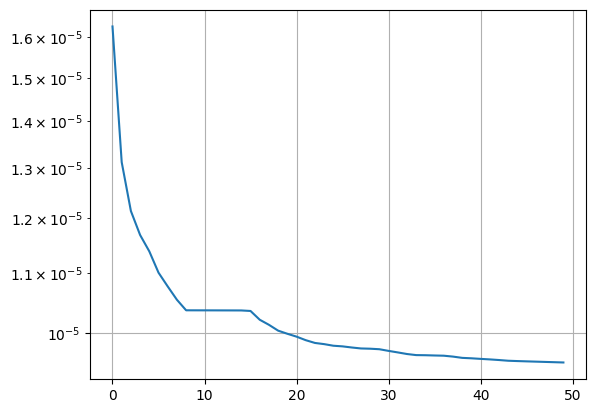

In [120]:
plt.semilogy(loss_lbfgs)
plt.grid()

In [121]:
total_loss = np.concatenate((loss_adam, loss_lbfgs))

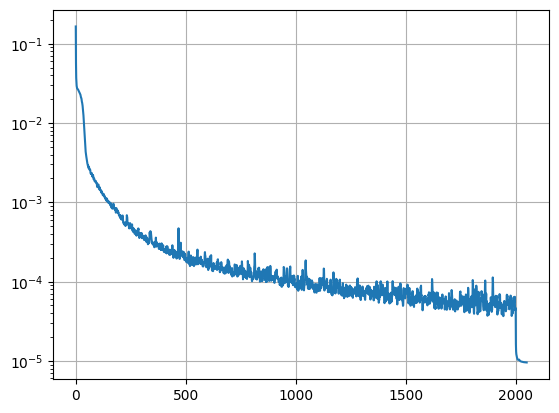

In [122]:
plt.semilogy(total_loss)
plt.grid()

In [123]:
A = jax.vmap(Cvar_model, [0, 0, None, None])(t, z_init_E_V, 0, Cparams)
F = jax.vmap(Cvar_model, [0, 0, None, None])(t, z_init_E_V, 1, Cparams)
G = jax.vmap(Cvar_model, [0, 0, None, None])(t, z_init_E_V, 2, Cparams)
E = (1/4)*((A**2/l**2) + (F**2/k**2) + (2*(G**2)/(k**2 + l**2)))
V = (1/2)*(A**2 + F**2 + 2*(G**2))

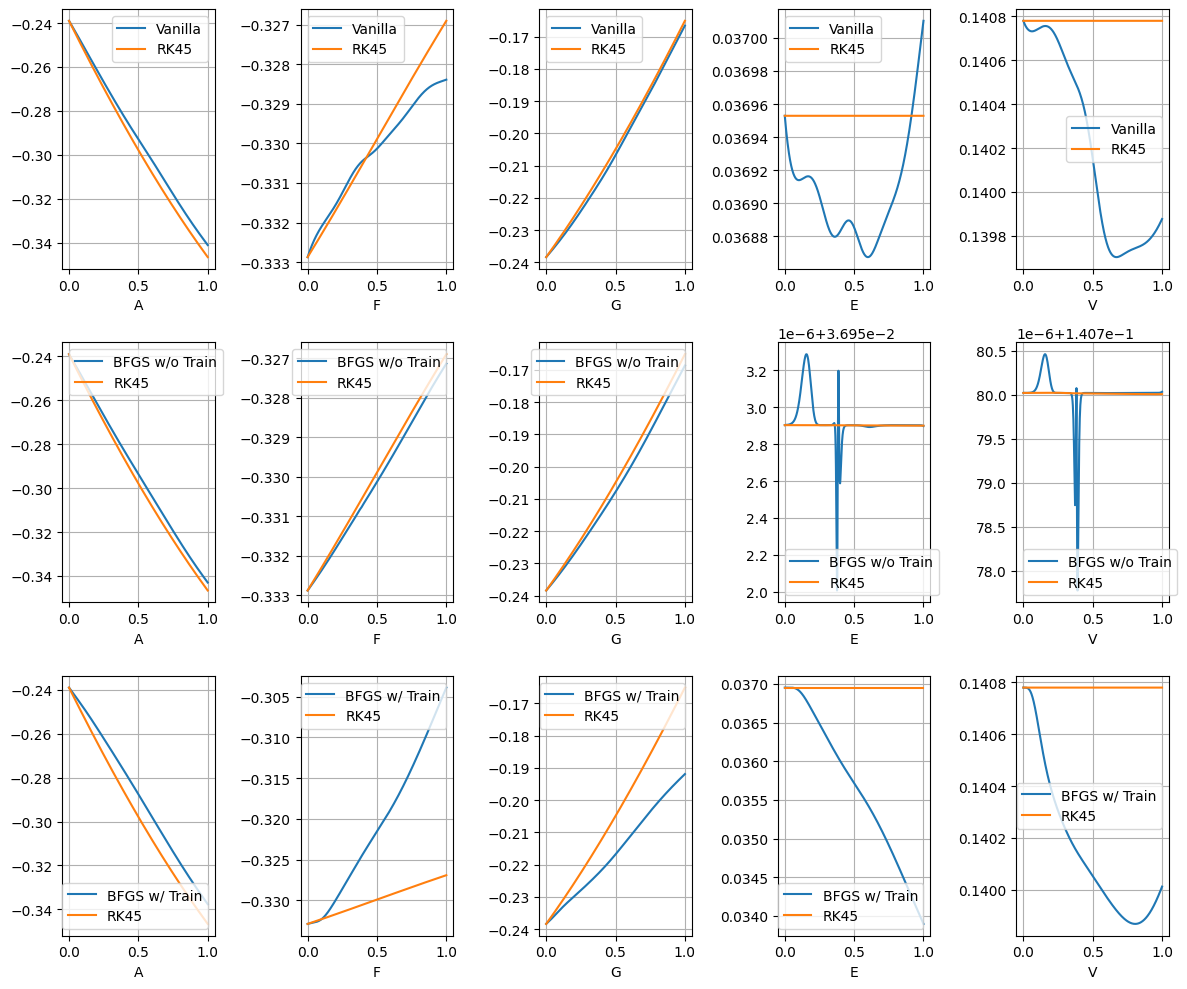

In [124]:
fig = plt.figure(figsize=(12, 10))

plt.subplot(3, 5, 1)
plt.tight_layout()
plt.plot(t, A_van)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(3, 5, 2)
plt.tight_layout()
plt.plot(t, F_van)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(3, 5, 3)
plt.tight_layout()
plt.plot(t, G_van)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(3, 5, 4)
plt.tight_layout()
plt.plot(t, E_van)
plt.plot(t, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['Vanilla','RK45'])


plt.subplot(3, 5, 5)
plt.tight_layout()
plt.plot(t, V_van)
plt.plot(t, V_rk)
plt.xlabel("V")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(3, 5, 6)
plt.tight_layout()
plt.plot(t, A_bfgs)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['BFGS w/o Train','RK45'])

plt.subplot(3, 5, 7)
plt.tight_layout()
plt.plot(t, F_bfgs)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['BFGS w/o Train','RK45'])

plt.subplot(3, 5, 8)
plt.tight_layout()
plt.plot(t, G_bfgs)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['BFGS w/o Train','RK45'])

plt.subplot(3, 5, 9)
plt.tight_layout()
plt.plot(t, E_bfgs)
plt.plot(t, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['BFGS w/o Train','RK45'])


plt.subplot(3, 5, 10)
plt.tight_layout()
plt.plot(t, V_bfgs)
plt.plot(t, V_rk)
plt.xlabel("V")
plt.grid()
plt.legend(['BFGS w/o Train','RK45'])


plt.subplot(3, 5, 11)
plt.tight_layout()
plt.plot(t, A)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['BFGS w/ Train','RK45'])

plt.subplot(3, 5, 12)
plt.tight_layout()
plt.plot(t, F)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['BFGS w/ Train','RK45'])

plt.subplot(3, 5, 13)
plt.tight_layout()
plt.plot(t, G)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['BFGS w/ Train','RK45'])

plt.subplot(3, 5, 14)
plt.tight_layout()
plt.plot(t, E)
plt.plot(t, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['BFGS w/ Train','RK45'])


plt.subplot(3, 5, 15)
plt.tight_layout()
plt.plot(t, V)
plt.plot(t, V_rk)
plt.xlabel("V")
plt.grid()
plt.legend(['BFGS w/ Train','RK45'])


plt.show()

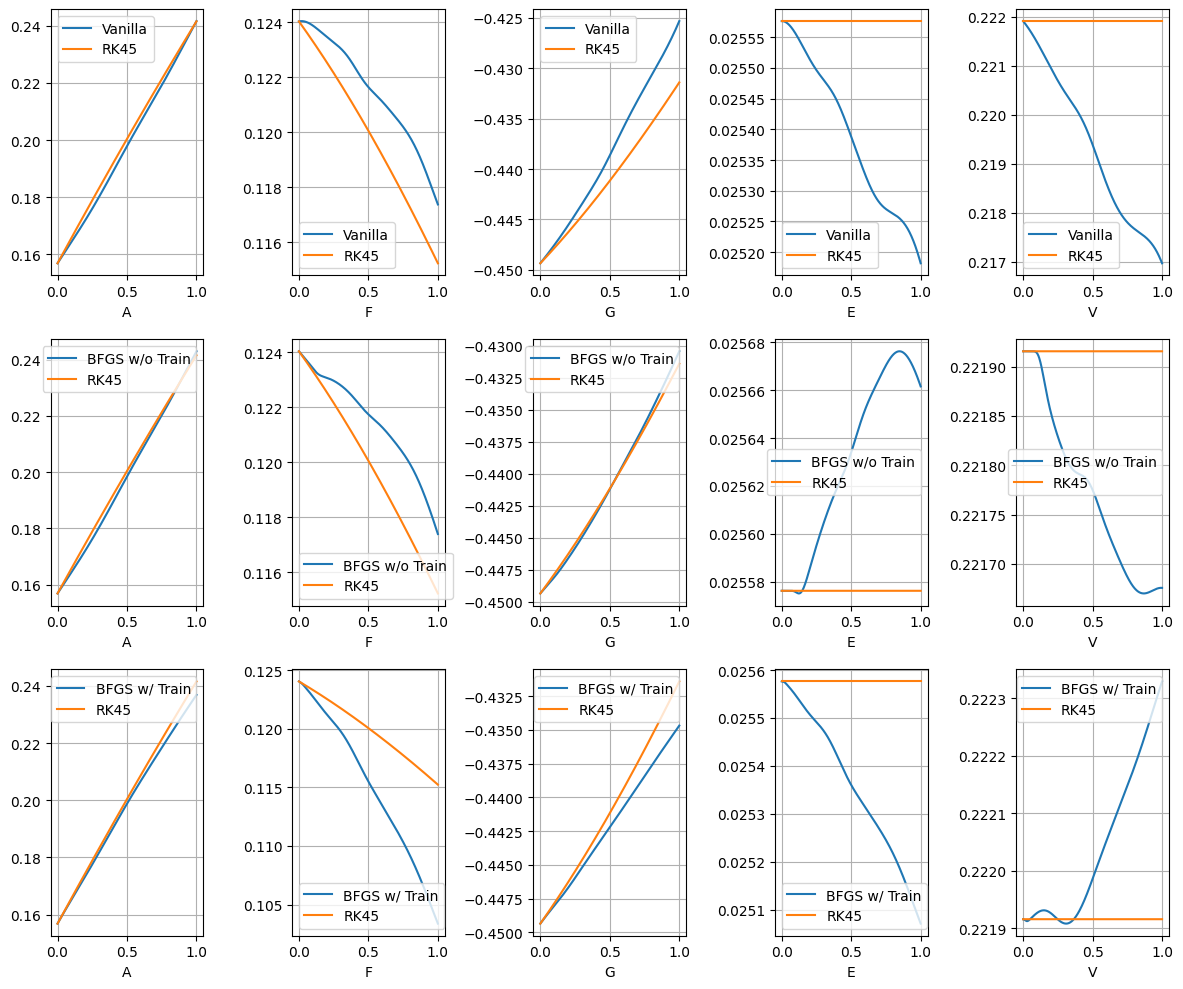

In [125]:
n = 500
t = np.linspace(t0, tfinal, n)

A_data = np.random.uniform(-1.0, 1.0, size=(1,))
F_data = np.random.uniform(-1.0, 1.0, size=(1,))
G_data = np.random.uniform(-1.0, 1.0, size=(1,))
E_data = (1/4)*((A_data**2/l**2) + (F_data**2/k**2) + (2*(G_data**2)/(k**2 + l**2)))
V_data = (1/2)*(A_data**2 + F_data**2 + 2*(G_data**2))

init_data = np.column_stack([A_data, F_data, G_data])
init_data_E_V = np.column_stack([A_data, F_data, G_data, E_data, V_data])

init_data = np.reshape(init_data, (-1,))
init_data_E_V = np.reshape(init_data_E_V, (-1,))

z_init = np.repeat(np.expand_dims(init_data, axis=0), len(t), axis=0)
z_init_E_V = np.repeat(np.expand_dims(init_data_E_V, axis=0), len(t), axis=0)


sol_rk = odeint(Lorenz1960, init_data, t)
A_rk, F_rk, G_rk = sol_rk[:,0], sol_rk[:,1], sol_rk[:,2]
E_rk = (1/4)*((A_rk**2/l**2) + (F_rk**2/k**2) + (2*(G_rk**2)/(k**2 + l**2)))
V_rk = (1/2)*(A_rk**2 + F_rk**2 + 2*(G_rk**2))

A_van = jax.vmap(var_model, [0, 0, None, None])(t, z_init_E_V, 0, params)
F_van = jax.vmap(var_model, [0, 0, None, None])(t, z_init_E_V, 1, params)
G_van = jax.vmap(var_model, [0, 0, None, None])(t, z_init_E_V, 2, params)
E_van = (1/4)*((A_van**2/l**2) + (F_van**2/k**2) + (2*(G_van**2)/(k**2 + l**2)))
V_van = (1/2)*(A_van**2 + F_van**2 + 2*(G_van**2))

z_van = jnp.column_stack([A_van, F_van, G_van, E_van, V_van])


AFG_vals = jnp.column_stack((A_van, F_van, G_van))
E_vals = z_init_E_V[:, 3:4]
V_vals = z_init_E_V[:, 4:]


x_bfgs = find_min_bfgs(AFG_vals, E_vals, V_vals)

A_bfgs = jnp.reshape(x_bfgs[:,:1], (-1,))
F_bfgs = jnp.reshape(x_bfgs[:,1:2], (-1,))
G_bfgs = jnp.reshape(x_bfgs[:,2:3], (-1,))
E_bfgs = (1/4)*((A_bfgs**2/l**2) + (F_bfgs**2/k**2) + (2*(G_bfgs**2)/(k**2 + l**2)))
V_bfgs = (1/2)*(A_bfgs**2 + F_bfgs**2 + 2*(G_bfgs**2))

A = jax.vmap(Cvar_model, [0, 0, None, None])(t, z_init_E_V, 0, Cparams)
F = jax.vmap(Cvar_model, [0, 0, None, None])(t, z_init_E_V, 1, Cparams)
G = jax.vmap(Cvar_model, [0, 0, None, None])(t, z_init_E_V, 2, Cparams)
E = (1/4)*((A**2/l**2) + (F**2/k**2) + (2*(G**2)/(k**2 + l**2)))
V = (1/2)*(A**2 + F**2 + 2*(G**2))


fig = plt.figure(figsize=(12, 10))

plt.subplot(3, 5, 1)
plt.tight_layout()
plt.plot(t, A_van)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(3, 5, 2)
plt.tight_layout()
plt.plot(t, F_van)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(3, 5, 3)
plt.tight_layout()
plt.plot(t, G_van)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(3, 5, 4)
plt.tight_layout()
plt.plot(t, E_van)
plt.plot(t, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['Vanilla','RK45'])


plt.subplot(3, 5, 5)
plt.tight_layout()
plt.plot(t, V_van)
plt.plot(t, V_rk)
plt.xlabel("V")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(3, 5, 6)
plt.tight_layout()
plt.plot(t, A_bfgs)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['BFGS w/o Train','RK45'])

plt.subplot(3, 5, 7)
plt.tight_layout()
plt.plot(t, F_bfgs)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['BFGS w/o Train','RK45'])

plt.subplot(3, 5, 8)
plt.tight_layout()
plt.plot(t, G_bfgs)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['BFGS w/o Train','RK45'])

plt.subplot(3, 5, 9)
plt.tight_layout()
plt.plot(t, E_bfgs)
plt.plot(t, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['BFGS w/o Train','RK45'])


plt.subplot(3, 5, 10)
plt.tight_layout()
plt.plot(t, V_bfgs)
plt.plot(t, V_rk)
plt.xlabel("V")
plt.grid()
plt.legend(['BFGS w/o Train','RK45'])


plt.subplot(3, 5, 11)
plt.tight_layout()
plt.plot(t, A)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['BFGS w/ Train','RK45'])

plt.subplot(3, 5, 12)
plt.tight_layout()
plt.plot(t, F)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['BFGS w/ Train','RK45'])

plt.subplot(3, 5, 13)
plt.tight_layout()
plt.plot(t, G)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['BFGS w/ Train','RK45'])

plt.subplot(3, 5, 14)
plt.tight_layout()
plt.plot(t, E)
plt.plot(t, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['BFGS w/ Train','RK45'])


plt.subplot(3, 5, 15)
plt.tight_layout()
plt.plot(t, V)
plt.plot(t, V_rk)
plt.xlabel("V")
plt.grid()
plt.legend(['BFGS w/ Train','RK45'])


plt.show()